In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv", encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df['Postal Code'] = df['Postal Code'].fillna(0)
print("Data ready!", df.shape)

Data ready! (9800, 18)


In [2]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales
count,9800.000000,9800,9800,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55211.280918,230.769059
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,0.000000,0.444000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,57551.000000,54.490000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,NaN,32076.677954,626.651875


In [3]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


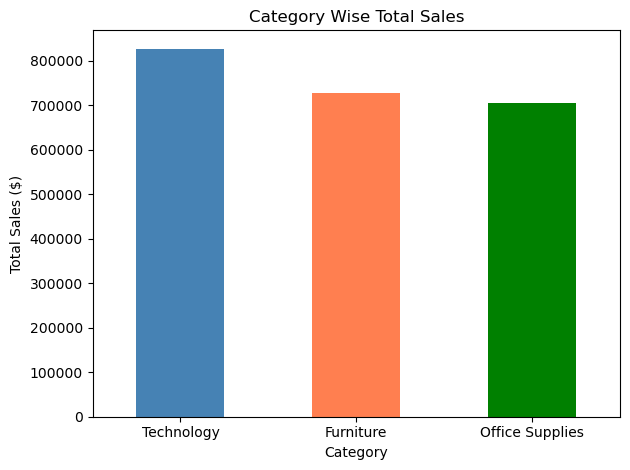

In [4]:
category_sales.plot(kind='bar', color=['steelblue', 'coral', 'green'])
plt.title('Category Wise Total Sales')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

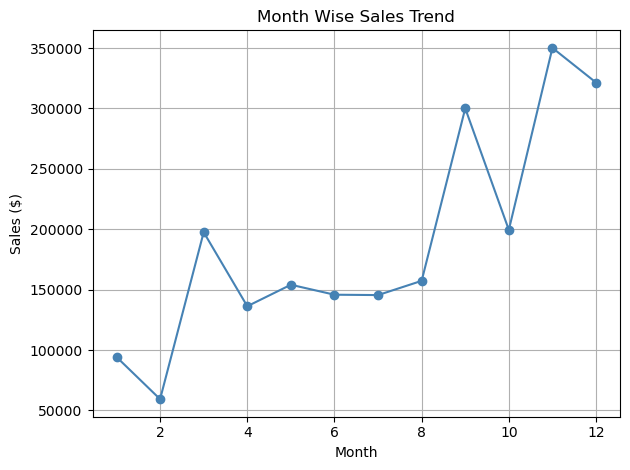

In [5]:
df['Month'] = df['Order Date'].dt.month

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='line', marker='o', color='steelblue')
plt.title('Month Wise Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Name: Sales, dtype: float64


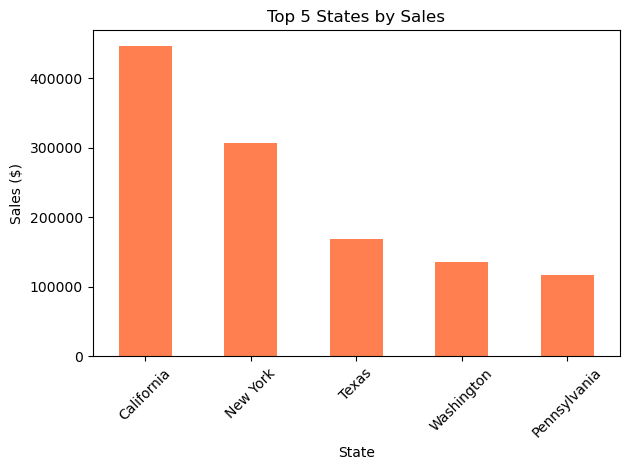

In [6]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(5)
print(top_states)

top_states.plot(kind='bar', color='coral')
plt.title('Top 5 States by Sales')
plt.xlabel('State')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

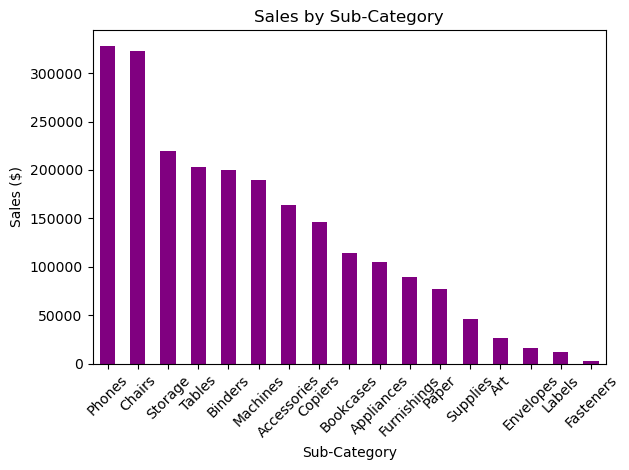

In [10]:
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

subcat_sales.plot(kind='bar', color='purple')
plt.title('Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

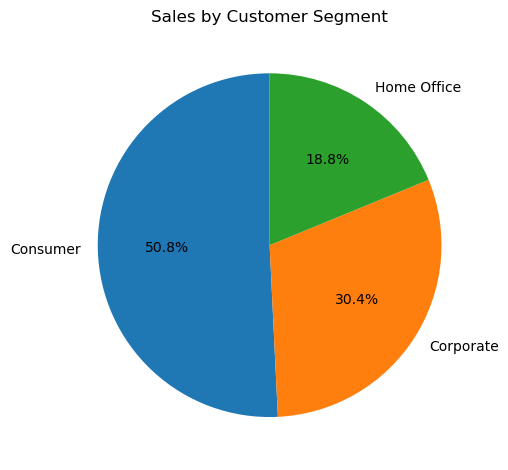

In [11]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Sales by Customer Segment')
plt.ylabel('')
plt.tight_layout()
plt.show()

## EDA Insights – Superstore Sales Data

### Dataset Overview
- Total Orders: 9800
- Total Columns: 18
- Data Period: January 2015 to December 2018
- Average Order Value: $230.77
- Maximum Single Order Value: $22,638

### Key Findings

1. **Category Wise Sales**
   - Technology: $827,455 — highest selling category
   - Furniture: $728,658 — second highest
   - Office Supplies: $705,422 — third
   - Technology is the clear winner in terms of total revenue

2. **Month Wise Sales Trend**
   - February is the slowest month with around $60,000 in sales
   - March shows a sudden spike reaching around $200,000
   - November is the peak month with approximately $350,000 in sales
   - Sales are consistently higher in the last quarter (Nov-Dec)
   - This is likely due to holiday season demand and year-end budgets

3. **Top 5 States by Sales**
   - California: ~$450,000 — ranked 1st by a large margin
   - New York: ~$307,000 — ranked 2nd
   - Texas: ~$170,000 — ranked 3rd
   - Washington and Pennsylvania also feature in the top 5

4. **Sub-Category Wise Sales**
   - Phones: ~$325,000 — top selling sub-category
   - Chairs: ~$320,000 — very close second
   - Storage and Tables are also strong performers
   - Fasteners generated the least revenue overall

5. **Customer Segment Wise Sales**
   - Consumer: 50.8% — largest segment
   - Corporate: 30.4% — second largest
   - Home Office: 18.8% — smallest segment
   - More than half of total sales come from Consumer segment

### Business Recommendations
1. Invest more in Technology products as they generate the highest revenue
2. Focus marketing efforts on California and New York
3. Run discount campaigns in February to boost sales in the slowest month
4. Prioritize the Consumer segment as it contributes over 50% of total sales
5. Always maintain stock of Phones and Chairs as they are top selling products

### Summary
The analysis shows that Technology is the best performing category,
California is the top state, and the Consumer segment drives the majority
of sales. Sales peak in November and drop sharply in February.
These insights can help the business plan inventory, marketing,
and sales strategies more effectively.